In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_final= pd.read_csv(r"C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao\data\processed\cleaned_air_quality_bilbao_2015_2026.csv")
df_final.head()

,Date,station,Town,Province,Latitude,Longitude,NO2,PM10,PM2.5,SO2
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.0,28.0,9.0
1,2015-01-02,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,56.0,24.0,18.0,8.0
2,2015-01-03,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,48.0,33.0,21.0,8.0
3,2015-01-04,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,43.0,31.0,23.0,7.0
4,2015-01-05,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,29.0,18.0,11.0,5.0


In [10]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 27883 entries, 0 to 27882
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       27883 non-null  str    
 1   station    27883 non-null  str    
 2   Town       27883 non-null  str    
 3   Province   27883 non-null  str    
 4   Latitude   27883 non-null  float64
 5   Longitude  27883 non-null  float64
 6   NO2        27883 non-null  float64
 7   PM10       27883 non-null  float64
 8   PM2.5      27883 non-null  float64
 9   SO2        27883 non-null  float64
dtypes: float64(6), str(4)
memory usage: 2.1 MB


In [11]:
df_final["Date"] = pd.to_datetime(df_final["Date"])
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 27883 entries, 0 to 27882
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       27883 non-null  datetime64[us]
 1   station    27883 non-null  str           
 2   Town       27883 non-null  str           
 3   Province   27883 non-null  str           
 4   Latitude   27883 non-null  float64       
 5   Longitude  27883 non-null  float64       
 6   NO2        27883 non-null  float64       
 7   PM10       27883 non-null  float64       
 8   PM2.5      27883 non-null  float64       
 9   SO2        27883 non-null  float64       
dtypes: datetime64[us](1), float64(6), str(3)
memory usage: 2.1 MB


In [5]:
df_final.isnull().sum()

Date         0
station      0
Town         0
Province     0
Latitude     0
Longitude    0
NO2          0
PM10         0
PM2.5        0
SO2          0
dtype: int64

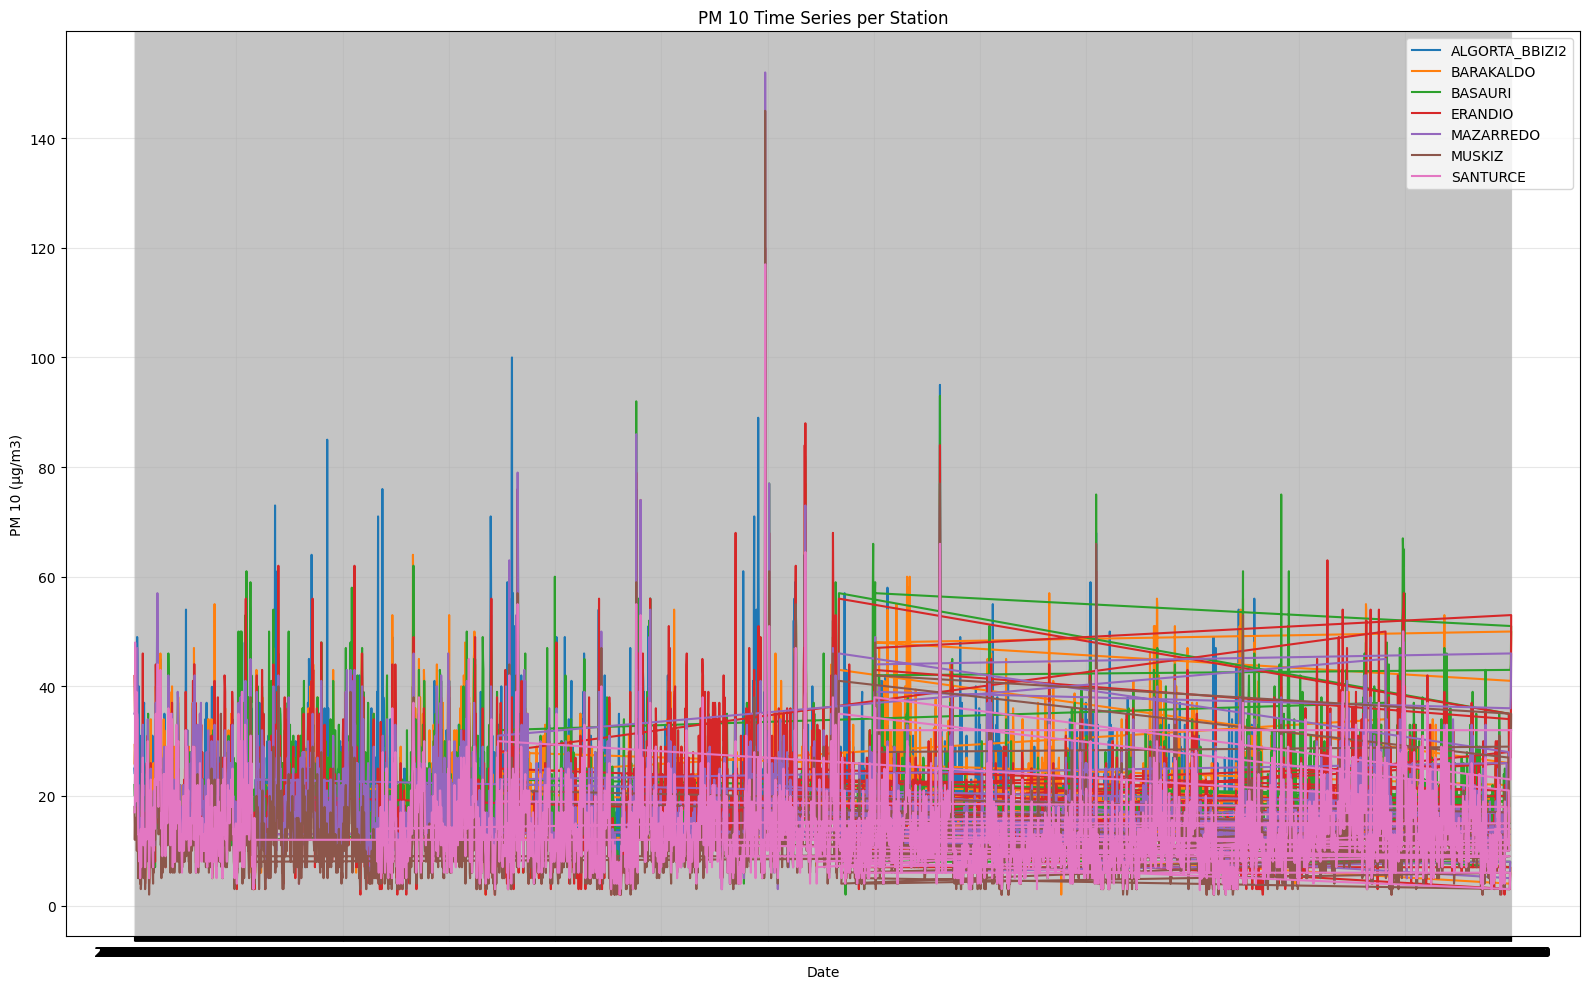

In [7]:
stations = df_final["station"].unique()

plt.figure(figsize=(16, 10))

for st in stations:
    sub = df_final[df_final["station"] == st]

    plt.plot(sub["Date"], sub["PM10"], label=st, linewidth=1.5)

plt.title("PM 10 Time Series per Station")
plt.xlabel("Date")
plt.ylabel("PM 10 (µg/m3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

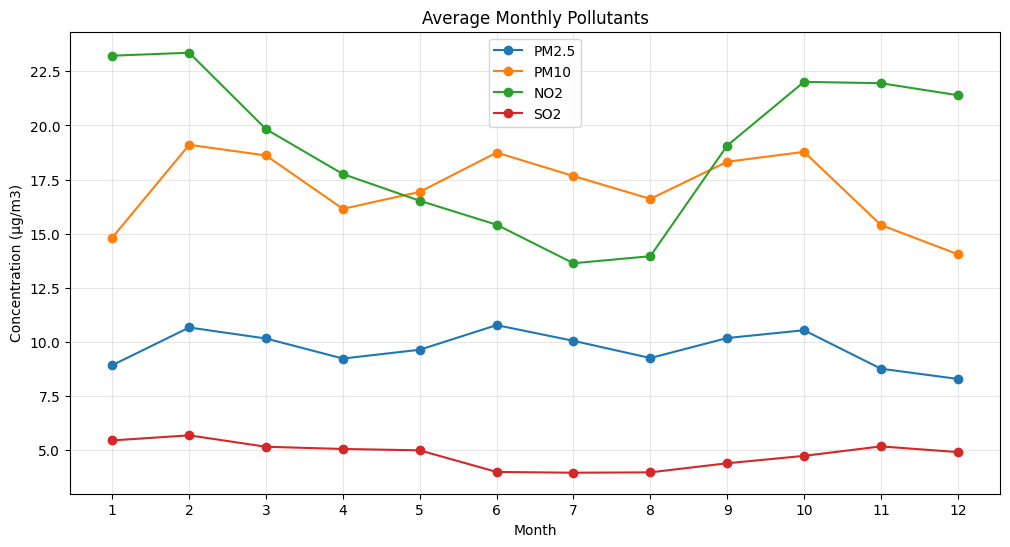

In [14]:
# ۱. استخراج ماه از ستون Date (در صورتی که قبلاً انجام نداده‌اید)
df_final['month'] = df_final['Date'].dt.month

# ۲. تعریف ستون‌های آلاینده جدید (دقیقاً مطابق نام ستون‌های شما)
pollutants = ["PM2.5", "PM10", "NO2", "SO2"]

# ۳. گروه بندی بر اساس ماه و محاسبه میانگین
monthly_all = df_final.groupby("month")[pollutants].mean()

# ۴. رسم نمودار
plt.figure(figsize=(12, 6))
for col in pollutants:
    plt.plot(monthly_all.index, monthly_all[col], marker="o", label=col)

plt.title("Average Monthly Pollutants")
plt.xlabel("Month")
plt.ylabel("Concentration (µg/m3)") # واحد را اینجا به صورت کلی اضافه می‌کنیم
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(1, 13)) # اطمینان از نمایش اعداد ۱ تا ۱۲ برای ماه‌ها
plt.show()

In [13]:
pollutants = ["PM2.5", "PM10", "NO2", "SO2"]

monthly_all = df_final.groupby("month")[pollutants].mean()

plt.figure(figsize=(12,6))
for col in pollutants:
    plt.plot(monthly_all.index, monthly_all[col], marker="o", label=col)

plt.title("Average Monthly Pollutants")
plt.xlabel("Month")
plt.ylabel("Concentration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

KeyError: 'month'